In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv(r'C:\Users\leepa\Documents\data_center_energy_prediction\data\processed\feateng_dataset.csv')
data
data=data.sort_values(['building_id'])

In [3]:
data.dtypes

building_id             int64
meter                   int64
meter_reading         float64
site_id                 int64
primary_use             int64
square_feet             int64
year_built            float64
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
hour                    int64
day                     int64
weekday                 int64
month                   int64
lag_1h                float64
lag_24h               float64
lag_48h               float64
y_1h                  float64
y_24h                 float64
y_48h                 float64
dtype: object

In [4]:
data

,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,...,hour,day,weekday,month,lag_1h,lag_24h,lag_48h,y_1h,y_24h,y_48h
0,167,0,57.5400,2,4,86323,1956.0,17.2,0.0,7.8,...,14,19,6,6,223.8830,61.1932,57.6800,280.9260,77.630000,85.9500
1,167,1,280.9260,2,4,86323,1956.0,17.2,0.0,7.8,...,6,22,2,6,57.5400,118.5200,31.7707,309.1310,324.500000,12.2035
2,167,1,309.1310,2,4,86323,1956.0,17.2,0.0,7.8,...,2,24,4,6,280.9260,11.7228,5.8614,2.9307,252.228667,2.9307
3,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,3,25,5,6,309.1310,82.0129,5.8614,2.9307,179.957333,83.9500
4,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,2,28,1,6,2.9307,78.2100,5.8614,61.9700,107.686000,23.4457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46849,1366,1,4.7588,15,6,87977,1947.0,17.2,0.0,7.8,...,0,25,0,4,5.3368,5.3815,5.3815,5.1528,22.457200,3.5774
46850,1366,1,5.1528,15,6,87977,1947.0,17.2,0.0,7.8,...,5,1,6,5,4.7588,5.3815,5.3815,415.8420,11.292200,41.1250
46851,1366,2,415.8420,15,6,87977,1947.0,17.2,0.0,7.8,...,17,2,0,5,5.1528,5.3815,5.3815,5.8154,272.771000,3.6024
46852,1366,1,5.8154,15,6,87977,1947.0,17.2,0.0,7.8,...,23,3,1,5,415.8420,5.3815,5.3815,248.7330,21.245000,97.0750


In [5]:
#seperate x and y for model training


x=data.drop(columns=['y_1h','y_24h','y_48h'])
x

,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,...,sea_level_pressure,wind_direction,wind_speed,hour,day,weekday,month,lag_1h,lag_24h,lag_48h
0,167,0,57.5400,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,14,19,6,6,223.8830,61.1932,57.6800
1,167,1,280.9260,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,6,22,2,6,57.5400,118.5200,31.7707
2,167,1,309.1310,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,2,24,4,6,280.9260,11.7228,5.8614
3,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,3,25,5,6,309.1310,82.0129,5.8614
4,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,2,28,1,6,2.9307,78.2100,5.8614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46849,1366,1,4.7588,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,0,25,0,4,5.3368,5.3815,5.3815
46850,1366,1,5.1528,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,5,1,6,5,4.7588,5.3815,5.3815
46851,1366,2,415.8420,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,17,2,0,5,5.1528,5.3815,5.3815
46852,1366,1,5.8154,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,23,3,1,5,415.8420,5.3815,5.3815


In [6]:
y_multi=data[['y_1h','y_24h','y_48h']]
y_multi

,y_1h,y_24h,y_48h
0,280.9260,77.630000,85.9500
1,309.1310,324.500000,12.2035
2,2.9307,252.228667,2.9307
3,2.9307,179.957333,83.9500
4,61.9700,107.686000,23.4457
...,...,...,...
46849,5.1528,22.457200,3.5774
46850,415.8420,11.292200,41.1250
46851,5.8154,272.771000,3.6024
46852,248.7330,21.245000,97.0750


In [7]:
#Train test and split 

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y_multi,train_size=0.7,random_state=42)
x_train

,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,...,sea_level_pressure,wind_direction,wind_speed,hour,day,weekday,month,lag_1h,lag_24h,lag_48h
30773,1211,2,1820.3100,13,6,94988,1970.0,8.3,0.0,6.7,...,1000.1,30.0,5.7,4,3,6,1,1820.3100,1820.3100,1820.3100
25638,945,2,646.6000,9,6,332447,1970.0,15.0,0.0,12.8,...,1010.8,170.0,1.5,10,2,5,1,646.6000,646.6000,646.6000
23503,914,2,427.0000,9,0,229973,1970.0,27.8,0.0,21.7,...,1009.4,130.0,4.6,11,2,5,1,427.0000,427.0000,427.0000
46712,1366,1,5.3815,15,6,87977,1947.0,18.9,4.0,11.1,...,1020.9,180.0,3.6,11,3,6,1,5.3815,5.3815,5.3815
17672,793,0,957.6400,7,0,150695,1964.0,-0.9,0.0,-3.1,...,1016.6,240.0,2.6,5,2,5,1,957.6400,957.6400,957.6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,244,3,60.9400,2,0,95717,1970.0,23.9,2.0,14.4,...,1013.0,160.0,1.5,10,1,4,1,60.9400,60.9400,60.9400
44732,1366,1,5.3815,15,6,87977,1947.0,23.3,0.0,20.6,...,1013.2,130.0,2.6,11,3,6,1,5.3815,5.3815,5.3815
38158,1318,0,61.9982,14,1,73488,1970.0,25.6,0.0,14.4,...,1017.3,70.0,2.6,7,3,6,1,61.9982,61.9982,61.9982
860,188,0,10.9200,2,6,23549,1941.0,22.8,0.0,-5.0,...,1008.1,250.0,1.5,8,1,4,1,10.9200,10.9200,10.9200


In [8]:
print(x.dtypes)

building_id             int64
meter                   int64
meter_reading         float64
site_id                 int64
primary_use             int64
square_feet             int64
year_built            float64
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
hour                    int64
day                     int64
weekday                 int64
month                   int64
lag_1h                float64
lag_24h               float64
lag_48h               float64
dtype: object


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

In [10]:
# Train a Mutli ouput model
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
model=RandomForestRegressor(n_estimators=400,max_depth=18,min_samples_split=5,min_samples_leaf=1,max_features='sqrt',random_state=42,n_jobs=-1)
multi_model=MultiOutputRegressor(model)
multi_model.fit(x_train, y_train)
ypred=multi_model.predict(x_test)
ypred
# # max_depth to 20
# n_estimators set to 400 trees and max_depth to 20 for optimal prediction and not memorization more like to avoid underfitting and overfitting
#  Check predictions for bias variance control

array([[ 65.33188149,  65.6051237 ,  65.93193092],
       [707.44893813, 707.33357479, 706.46490767],
       [  8.7921    ,   8.7921    ,   8.8318572 ],
       ...,
       [163.08806338, 163.06782443, 163.09291444],
       [ 77.10179097,  77.31833514,  77.66548763],
       [426.97049246, 418.36604679, 425.82303773]], shape=(14057, 3))

In [11]:
data.head(10)

,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,...,hour,day,weekday,month,lag_1h,lag_24h,lag_48h,y_1h,y_24h,y_48h
0,167,0,57.5400,2,4,86323,1956.0,17.2,0.0,7.8,...,14,19,6,6,223.8830,61.1932,57.6800,280.9260,77.630000,85.9500
1,167,1,280.9260,2,4,86323,1956.0,17.2,0.0,7.8,...,6,22,2,6,57.5400,118.5200,31.7707,309.1310,324.500000,12.2035
2,167,1,309.1310,2,4,86323,1956.0,17.2,0.0,7.8,...,2,24,4,6,280.9260,11.7228,5.8614,2.9307,252.228667,2.9307
3,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,3,25,5,6,309.1310,82.0129,5.8614,2.9307,179.957333,83.9500
4,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,2,28,1,6,2.9307,78.2100,5.8614,61.9700,107.686000,23.4457
5,167,0,61.9700,2,4,86323,1956.0,17.2,0.0,7.8,...,6,4,0,7,2.9307,67.4532,65.4100,319.2600,76.430000,41.0299
6,167,1,319.2600,2,4,86323,1956.0,17.2,0.0,7.8,...,15,5,1,7,61.9700,2.9307,98.6125,66.8500,100.310000,83.5700
7,167,0,66.8500,2,4,86323,1956.0,17.2,0.0,7.8,...,20,6,2,7,319.2600,2.9307,0.3165,286.2010,147.831333,42.3301
8,167,1,286.2010,2,4,86323,1956.0,17.2,0.0,7.8,...,5,14,3,7,66.8500,5.8614,17.5843,66.9400,195.352667,1.0902
9,167,0,66.9400,2,4,86323,1956.0,17.2,0.0,7.8,...,3,15,4,7,286.2010,139.5840,12.7662,64.2300,242.874000,35.1685


In [12]:
print(data.dtypes)

building_id             int64
meter                   int64
meter_reading         float64
site_id                 int64
primary_use             int64
square_feet             int64
year_built            float64
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
hour                    int64
day                     int64
weekday                 int64
month                   int64
lag_1h                float64
lag_24h               float64
lag_48h               float64
y_1h                  float64
y_24h                 float64
y_48h                 float64
dtype: object


In [13]:
x

,building_id,meter,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,...,sea_level_pressure,wind_direction,wind_speed,hour,day,weekday,month,lag_1h,lag_24h,lag_48h
0,167,0,57.5400,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,14,19,6,6,223.8830,61.1932,57.6800
1,167,1,280.9260,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,6,22,2,6,57.5400,118.5200,31.7707
2,167,1,309.1310,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,2,24,4,6,280.9260,11.7228,5.8614
3,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,3,25,5,6,309.1310,82.0129,5.8614
4,167,3,2.9307,2,4,86323,1956.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,2,28,1,6,2.9307,78.2100,5.8614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46849,1366,1,4.7588,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,0,25,0,4,5.3368,5.3815,5.3815
46850,1366,1,5.1528,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,5,1,6,5,4.7588,5.3815,5.3815
46851,1366,2,415.8420,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,17,2,0,5,5.1528,5.3815,5.3815
46852,1366,1,5.8154,15,6,87977,1947.0,17.2,0.0,7.8,...,1015.9,160.0,3.1,23,3,1,5,415.8420,5.3815,5.3815


In [14]:
y_multi

,y_1h,y_24h,y_48h
0,280.9260,77.630000,85.9500
1,309.1310,324.500000,12.2035
2,2.9307,252.228667,2.9307
3,2.9307,179.957333,83.9500
4,61.9700,107.686000,23.4457
...,...,...,...
46849,5.1528,22.457200,3.5774
46850,415.8420,11.292200,41.1250
46851,5.8154,272.771000,3.6024
46852,248.7330,21.245000,97.0750


In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

In [16]:
MAE=mean_absolute_error(y_test,ypred)
MAE

13.176987594732855

In [17]:
MSE=mean_squared_error(y_test,ypred)
MSE

20922.474962549877

In [18]:
R2=r2_score(y_test,ypred)
R2

0.9691865979317468

In [19]:
RMSE=root_mean_squared_error(y_test,ypred)
RMSE

138.34157088961135

In [20]:
x.columns

Index(['building_id', 'meter', 'meter_reading', 'site_id', 'primary_use',
       'square_feet', 'year_built', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month',
       'lag_1h', 'lag_24h', 'lag_48h'],
      dtype='str')

In [21]:


#Columns must match exact columns
predict=pd.DataFrame([[1,0,300,1,4,78797,2016.0,18.6,0.0,9.5,0,1,1,34,17,2,2,1,123,156,340]],columns=x_train.columns)


#predict= np.array([[2000, 0, 300, 1, 4, 89797, 2016.0, 15.6, 0.0, 9.5, 0, 1, 1,34, 17,2,2,1,123,156,390]])
#This produces Userwarning so we are doing input as a dataframe


y_new_pred=multi_model.predict(predict)
print("Predicted Energy Usage:")
print("y1h:", y_new_pred[0,0], "kWh")
print("y24h:", y_new_pred[0,1], "kWh")
print("y48h:", y_new_pred[0,2], "kWh")

Predicted Energy Usage:
y1h: 543.9573552954437 kWh
y24h: 606.0213507756107 kWh
y48h: 448.92639711031603 kWh


In [22]:
# #Hyperparameter tuning for better Performance 
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np

# multi_model=MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1))

# param_dist = {
#     "estimator__n_estimators": [200, 300, 400, 500],
#     "estimator__max_depth": [15, 18, 20, 22, None],
#     "estimator__min_samples_leaf": [1, 2, 4],
#     "estimator__min_samples_split": [2, 5, 10],
#     "estimator__max_features": ["sqrt"]
# }

# #Creating randomizedsearchcv 
# tune = RandomizedSearchCV(
#     estimator=multi_model,
#     param_distributions=param_dist,
#     n_iter=10,                       
#     scoring="neg_mean_squared_error",
#     cv=3,                             
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# tune.fit(x_train, y_train)

# best_model = tune.best_estimator_

# print("Best parameters found:")
# print(tune.best_params_)


# y_pred=best_model.predict(x_test)
# rmse=np.sqrt(mean_squared_error(y_test, y_pred))
# r2=r2_score(y_test, y_pred)
# print("Tuned RMSE:", rmse)
# print("Tuned R2:", r2)

In [23]:
# import matplotlib.pyplot as plt

# # Select rows you want
# start, end =50,1399

# plt.scatter(y_test.iloc[start:end, 0], [start:end, 0], alpha=0.6)
# plt.plot([y_test.iloc[start:end, 0].min(), y_test.iloc[start:end, 0].max()],
#          [y_test.iloc[start:end, 0].min(), y_test.iloc[start:end, 0].max()],'r--')
# plt.xlabel('Actual y1h')
# plt.ylabel('Predicted y1h')
# plt.title('Actual vs Predicted y1h')
# plt.show()

In [24]:
#Saving the Project
import joblib 
joblib.dump(multi_model,'../final_model.pkl')

['../final_model.pkl']

In [25]:
data.columns

Index(['building_id', 'meter', 'meter_reading', 'site_id', 'primary_use',
       'square_feet', 'year_built', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month',
       'lag_1h', 'lag_24h', 'lag_48h', 'y_1h', 'y_24h', 'y_48h'],
      dtype='str')

In [26]:
data.columns

Index(['building_id', 'meter', 'meter_reading', 'site_id', 'primary_use',
       'square_feet', 'year_built', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month',
       'lag_1h', 'lag_24h', 'lag_48h', 'y_1h', 'y_24h', 'y_48h'],
      dtype='str')

In [27]:
data.dtypes

building_id             int64
meter                   int64
meter_reading         float64
site_id                 int64
primary_use             int64
square_feet             int64
year_built            float64
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
hour                    int64
day                     int64
weekday                 int64
month                   int64
lag_1h                float64
lag_24h               float64
lag_48h               float64
y_1h                  float64
y_24h                 float64
y_48h                 float64
dtype: object

In [28]:
numeric=data.select_dtypes(include=['int64','float64']).columns
print("numeric columns:",numeric)

numeric columns: Index(['building_id', 'meter', 'meter_reading', 'site_id', 'primary_use',
       'square_feet', 'year_built', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'hour', 'day', 'weekday', 'month',
       'lag_1h', 'lag_24h', 'lag_48h', 'y_1h', 'y_24h', 'y_48h'],
      dtype='str')


In [29]:
minmax=data[numeric].agg(['min','max']).T
print(minmax)

                          min        max
building_id          167.0000    1366.00
meter                  0.0000       3.00
meter_reading          0.0200    9070.27
site_id                2.0000      15.00
primary_use            0.0000       6.00
square_feet         8836.0000  745671.00
year_built          1930.0000    2007.00
air_temperature      -25.6000      47.20
cloud_coverage         0.0000       9.00
dew_temperature      -29.4000      25.60
precip_depth_1_hr     -1.0000     333.00
sea_level_pressure   981.6000    1040.20
wind_direction         0.0000     360.00
wind_speed             0.0000      16.00
hour                   0.0000      23.00
day                    1.0000      31.00
weekday                0.0000       6.00
month                  1.0000       8.00
lag_1h                 0.0200    9070.27
lag_24h                0.0300   10565.30
lag_48h                0.1129   11767.00
y_1h                   0.0200    9070.27
y_24h                  0.0200    6850.66
y_48h           

In [30]:
print(data["building_id"].astype(str).to_list())



['167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '167', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188', '188'

In [31]:
print(data["square_feet"].astype(str).to_list())

['86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '86323', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', '23549', 

In [32]:
print(data["meter_reading"].astype(str).to_list())

['57.54', '280.926', '309.131', '2.9307', '2.9307', '61.97', '319.26', '66.85', '286.201', '66.94', '64.23', '342.04900000000004', '342.629', '343.209', '353.514', '331.25199999999995', '63.08', '338.216', '401.167', '403.066', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92', '10.92'

In [33]:
print(x_train.head())

       building_id  meter  meter_reading  site_id  primary_use  square_feet  \
30773         1211      2      1820.3100       13            6        94988   
25638          945      2       646.6000        9            6       332447   
23503          914      2       427.0000        9            0       229973   
46712         1366      1         5.3815       15            6        87977   
17672          793      0       957.6400        7            0       150695   

       year_built  air_temperature  cloud_coverage  dew_temperature  ...  \
30773      1970.0              8.3             0.0              6.7  ...   
25638      1970.0             15.0             0.0             12.8  ...   
23503      1970.0             27.8             0.0             21.7  ...   
46712      1947.0             18.9             4.0             11.1  ...   
17672      1964.0             -0.9             0.0             -3.1  ...   

       sea_level_pressure  wind_direction  wind_speed  hour  day  we

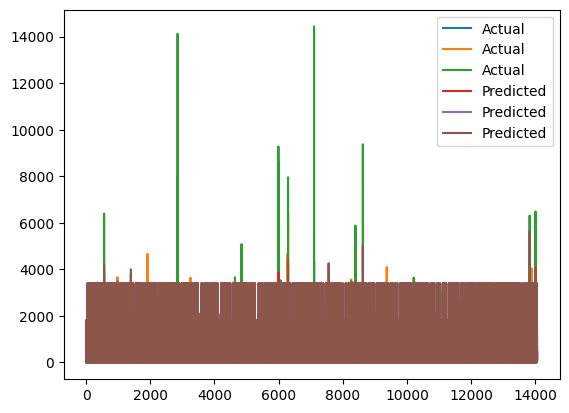

In [34]:
plt.plot(y_test.values,label='Actual')
plt.plot(ypred,label='Predicted')   
plt.legend()
plt.show()          

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predict on training data
y_pred_train=multi_model.predict(x_train)

# Predict on test data
y_pred_test=multi_model.predict(x_test)

In [36]:
# Training metrics
mae_train_1h=mean_absolute_error(y_train.iloc[:, 0], y_pred_train[:, 0])
mae_train_24h=mean_absolute_error(y_train.iloc[:, 1], y_pred_train[:, 1])
mae_train_48h=mean_absolute_error(y_train.iloc[:, 2], y_pred_train[:, 2])

r2_train_1h=r2_score(y_train.iloc[:, 0], y_pred_train[:, 0])
r2_train_24h=r2_score(y_train.iloc[:, 1], y_pred_train[:, 1])
r2_train_48h=r2_score(y_train.iloc[:, 2], y_pred_train[:, 2])

# Test metrics
mae_test_1h=mean_absolute_error(y_test.iloc[:, 0], y_pred_test[:, 0])
mae_test_24h=mean_absolute_error(y_test.iloc[:, 1], y_pred_test[:, 1])
mae_test_48h=mean_absolute_error(y_test.iloc[:, 2], y_pred_test[:, 2])

r2_test_1h=r2_score(y_test.iloc[:, 0], y_pred_test[:, 0])
r2_test_24h=r2_score(y_test.iloc[:, 1], y_pred_test[:, 1])
r2_test_48h=r2_score(y_test.iloc[:, 2], y_pred_test[:, 2])

In [37]:
print('1 hour horizon')
print('Train MAE:',mae_train_1h,'Test MAE:',mae_test_1h)
print('Train R2:',r2_train_1h,'Test R2:',r2_test_1h)

print('24 hour horizon')
print('Train MAE:',mae_train_24h,'Test MAE:',mae_test_24h)
print('Train R2:',r2_train_24h,'Test R2:',r2_test_24h)

print('48 hour horizon')
print('Train MAE:',mae_train_48h, 'Test MAE:',mae_test_48h)
print('Train R2:',r2_train_48h,'Test R2:',r2_test_48h)

1 hour horizon
Train MAE: 3.779205437223731 Test MAE: 7.8337501074148115
Train R2: 0.9964676597119274 Test R2: 0.9850945693441915
24 hour horizon
Train MAE: 7.322956817955328 Test MAE: 13.241114593436569
Train R2: 0.9939350985678082 Test R2: 0.9785547420553609
48 hour horizon
Train MAE: 10.060833270563785 Test MAE: 18.456098083347182
Train R2: 0.989989529400665 Test R2: 0.9439104823956878
